# VAJE 1: Uvod v strojno učenje in Numpy

Na vajah pri tem predmetu si bomo ogledali pristope k strojnemu učenju in kako jih pravilno uporabiti.

Vprašanje: Kaj je razlika med umetno inteligenco in strojnim učenjem?

Odgovor:
<details>
Strojno učenje je področje umetne inteligence, kjer se model uči in izboljšuje, najpogosteje s pomočjo podatkov.
</details>

Zelo pomembno je, da znamo podatke učinkovito predstaviti in z njimi delati. Podatki se lahko pojavijo v različnih oblikah: kot tabele, slike, besedilo, video, zvok, ... Ne glede na tip podatkov, jih skoraj v vseh primerih predstavimo kot tabele, oz. matematično bolj pravilno, kot tenzorje (večdimenzionalne matrike).

Poglejmo si torej kako podatke predstavimo in kako z njimi delamo.

## Naloga 1: Python seznami

V Pythonu tabele in tenzorje predstavimo s seznami. Te lahko definiramo na različne načine.

In [37]:
# Neposredna definicija
matrix = [[1, 2, 3],
          [4, 5, 6]]
print("Neposredna definicija matrike")
print(matrix)

# Dodajane elementov z iteracijo
matrix2 = []
for i in range(5):
    row = []
    for j in range(3):
        row.append(j)
    matrix2.append(row)
print("Matrika definirana z iteriranjem.")
print(matrix2)

# List comprehension
matrix3 = [[(j+1)*(i+1) for j in range(3)] for i in range(3)]
print("Matrika definirana z list comprehension-om.")
print(matrix3)

# V primeru, da imamo 2D matriko, lahko število vrstic dobimo s funkcijo len()
print("Število vrstic matrike")
print(len(matrix2))

# Za število stolpcev pa moramo pogledati dolžino vsake vrstice posebej
# ali predpostaviti, da so vse vrstice enako dolge
print("Število stolpcev matrike")
print(len(matrix2[0]))

Neposredna definicija matrike
[[1, 2, 3], [4, 5, 6]]
Matrika definirana z iteriranjem.
[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]]
Matrika definirana z list comprehension-om.
[[1, 2, 3], [2, 4, 6], [3, 6, 9]]
Število vrstic matrike
5
Število stolpcev matrike
3


Seznami lahko vsebujejo različne tipe podatkov naenkrat. Do elementov v seznamu pa dostopamo z oglatimi oklepaji.

In [38]:
# Seznam z elementi različnih tipov
matrix4 = [1, 1.5, "a", [1, 2, 4]]

# Dostop do druge vrstice seznama. Indeksi se začnejo z 0, zato je indeks drugega elementa 1
print("Drugi element")
print(matrix[1])

# Dostop do elementa v drugi vrstici in tretjem stolpcu
print("Element v drugi vrstici in tretjem stolpcu")
print(matrix[1][2])

# Elemente v seznamu lahko naslavljamo tudi od zadaj. V tem primeru je -1 zadnji element, -2 predzadnji, ...
print("Element v predzadnji vrstici in zadnjem stolpci")
print(matrix[-2][-1])

# Do stolpcev je bolj nadležno dostopati. To lahko naredimo z for zanko ali list comprehension-om
print("Drugi stolpec matrike")
drugi_stolpec = []
for row in matrix:
    drugi_stolpec.append(row[1])
print(drugi_stolpec)

drugi_stolpec = [row[1] for row in matrix]
print(drugi_stolpec)

Drugi element
[4, 5, 6]
Element v drugi vrstici in tretjem stolpcu
6
Element v predzadnji vrstici in zadnjem stolpci
3
Drugi stolpec matrike
[2, 5]
[2, 5]


1.a: Dopolni spodnjo funkcijo, ki matrično zmnoži dve 2D matriki/tenzorja.

In [39]:
def matricno_mnozenje(A: list[list[float]], B: list[list[float]]) -> list[list[float]]:
    # A: m x n, B: n x p
    if not A or not B:
        return []

    # Preverimo, če so matrike pravilno oblikovane (vsaka vrstica enake dolžine)
    n = len(A)
    m = len(A[0])
    if any(len(row) != m for row in A):
        raise ValueError("Prva matrika ni pravilno oblikovana (vrstice niso enake dolžine)")

    if any(len(row) != len(B[0]) for row in B):
        raise ValueError("Druga matrika ni pravilno oblikovana (vrstice niso enake dolžine)")

    if m != len(B):
        raise ValueError("Dimenzije se ne ujemajo za matrično množenje")

    p = len(B[0])
    rezultat = [[0.0 for _ in range(p)] for _ in range(n)]

    for i in range(n):
        for j in range(p):
            s = 0.0
            for k in range(m):
                s += A[i][k] * B[k][j]
            rezultat[i][j] = s

    return rezultat

Preverimo zgoraj definirano funkcijo na matrikah z naključnimi elementi ter poglejmo koliko časa potrebujemo za zmnožek dveh matrik velikosti 100x100.

In [40]:
# Naložiti moramo knjižnici, ki bosta generirali naključna števila in merila čas
import random
import time

In [41]:
A = [[1,2,3],
     [4,5,6]]

B = [[1,2,3],
     [4,5,6],
     [7,8,9]]
AxB = matricno_mnozenje(A, B)
print(AxB)

A = []
B = []
for i in range(100):
    A.append([random.random() for j in range(100)])
    B.append([random.random() for j in range(100)])

start_time = time.time()
AxB = matricno_mnozenje(A, B)
print(f"Time needed: {time.time() - start_time} seconds")

[[30.0, 36.0, 42.0], [66.0, 81.0, 96.0]]
Time needed: 0.13650918006896973 seconds


## Naloga 2: Numpy

Delo s Python seznami je nerodno in neučinkovito, poleg tega pa hitro pride do napak, saj težko nadzorujemo obliko tenzorjev in tip elementov v njih. Ena izmed rešitev je knjižnica Numpy.

Numpy je najbolj popularna Python knjižnica, ki omogoča preprosto in učinkovito delo s tenzorji. Vsebuje funkcije, ki uporabniku omogočajo preprosto definicijo in spreminjanje tenzorjev, uporabo matematičnih operacij na njih in še veliko več.

In [42]:
# Naložimo knjižnico numpy
import numpy as np

Poglejmo najprej nekaj načinov, kako lahko tenzor definiramo

In [43]:
# Python seznam lahko pretvorimo v tenzor (numpy array) z ukazom np.array()
print("Tenzor iz Python seznama")
matrix = np.array([[1,2], [3, 4]])
print(matrix)

# Numpy tenzor lahko definiramo tudi neposredno
# Za tenzor ničel lahko uporabimo ukaz np.zeros()
print("Matrika ničel velikosti 2x3")
matrix = np.zeros((2,3))
print(matrix)

# Za tenzor enice lahko uporabimo ukaz np.ones()
print("Matrika enic velikosti 3x2")
matrix = np.ones((3, 2))
print(matrix)

# Tudi tenzorje z naključnimi števili lahko definiramo z Numpy-jem
# Za tenzorje, ki vsebujejo Gaussovo porazdeljena števila, uporabimo ukaz np.random.normal(mean, standard deviation)
print("Matrika velikosti 3x2 z Gaussovo porazdeljenimi števili s parametri mean=10, standard deviation=5")
matrix = np.random.normal(10, 5, (3, 2))
print(matrix)

# Za tenzorje, ki vsebujejo števila med 0 in 1, uporabimo ukaz np.random.random()
print("Matrika naključnih števil med 0 in 1 velikosti 3x3")
matrix = np.random.random((3, 3))
print(matrix)

# Dimenzije tenzorjev lahko preverimo z ukazom .shape
print("Dimenzije tenzorjev")
print(matrix.shape)

print("Velikost prve dimenzije")
print(matrix.shape[0])


Tenzor iz Python seznama
[[1 2]
 [3 4]]
Matrika ničel velikosti 2x3
[[0. 0. 0.]
 [0. 0. 0.]]
Matrika enic velikosti 3x2
[[1. 1.]
 [1. 1.]
 [1. 1.]]
Matrika velikosti 3x2 z Gaussovo porazdeljenimi števili s parametri mean=10, standard deviation=5
[[ 2.73768569  1.30562486]
 [17.93226011 13.7354018 ]
 [13.81032971  4.38247937]]
Matrika naključnih števil med 0 in 1 velikosti 3x3
[[0.59754312 0.6666319  0.36447064]
 [0.6134241  0.09872068 0.12273545]
 [0.51216985 0.59989728 0.37450042]]
Dimenzije tenzorjev
(3, 3)
Velikost prve dimenzije
3


Če je bilo manipuliranje Python seznamov nerodno, je uporabljanje matematičnih funkcij na Numpy tenzorjih preprosto. Tu ne delamo na posameznih elementih, ampak na vseh elementih v matriki. Temu rečemo vektorske operacije.

In [44]:
# tenzor lahko množimo s skalarjem ali z drugim tenzorjem
print("Množenje matrike s skalarjem")
matrix = matrix * 10
print(matrix)

print("Hadamardov produkt matrike z vektorjem [1, 0, 1] (Množenje po elementih)")
print(matrix * np.array([1, 0, 1]))

# Podobno lahko na tenzorjih delamo matrično množenje.
# Uporabimo lahko ukaz np.dot, np.matmul ali operator @ (ki je okrajšava za funkcijo np.matmul).
# np.dot dovoljuje tudi množenje s skalarjem in se na 3+D matrikah obnaša drugače kot np.matmul.
print("Matrično množenje matrike z vektorjem [1, 0, 1]")
print(np.matmul(matrix, np.array([1, 0, 1])))

print("Matrično množenje matrike same s sabo")
print(matrix @ matrix)

# Matrikam lahko tudi prištevamo skalarje in vektorje
print("Seštevanje matrike s skalarjem 1")
print(matrix + 1)

print("Seštevanje matrike z vektorjem [1, 0, 1]")
print(matrix + np.array([1, 0, 1]))

Množenje matrike s skalarjem
[[5.97543123 6.66631901 3.64470644]
 [6.13424098 0.98720676 1.22735447]
 [5.12169852 5.99897284 3.74500418]]
Hadamardov produkt matrike z vektorjem [1, 0, 1] (Množenje po elementih)
[[5.97543123 0.         3.64470644]
 [6.13424098 0.         1.22735447]
 [5.12169852 0.         3.74500418]]
Matrično množenje matrike z vektorjem [1, 0, 1]
[9.62013767 7.36159545 8.8667027 ]
Matrično množenje matrike same s sabo
[[95.26567328 68.27966095 43.61006999]
 [48.99663888 49.23025059 28.16560786]
 [86.58428471 62.53128112 40.05501003]]
Seštevanje matrike s skalarjem 1
[[6.97543123 7.66631901 4.64470644]
 [7.13424098 1.98720676 2.22735447]
 [6.12169852 6.99897284 4.74500418]]
Seštevanje matrike z vektorjem [1, 0, 1]
[[6.97543123 6.66631901 4.64470644]
 [7.13424098 0.98720676 2.22735447]
 [6.12169852 5.99897284 4.74500418]]


Numpy nam omogoča tudi manipulacijo tenzorjev z drugimi matematičnimi funkcijami in preprosto indeksiranje.

In [45]:
# Potenciranje elementov v matriki
print("Potenciranje elementov v matriki")
print(np.power(matrix, 2))

# Sinus elementov v matriki
print("Sinus elementov v matriki")
print(np.sin(matrix))

# Uporabimo lahko tudi funkcije, ki delujejo na vseh elementih v matriki. Na primer seštevamo vse elemente v matriki ali le elemente po stolpcih ali vrsticah.
print("Seštevek vseh elementov v matriki")
print(np.sum(matrix))

print("Seštevek po stolpcih v matriki")
print(np.sum(matrix, axis=0))

print("Seštevek po vrsticah v matriki")
print(np.sum(matrix, axis=1))

# Če nas zanima le določena vrstica ali stolpec, lahko izberemo le tega ali več teh
# Dvopičje znotraj oglatih oklepajev označuje vse elemente v določeni dimenziji

print("Seštevek prve vrstice v matriki")
print(np.sum(matrix[0]))
print(np.sum(matrix[0, :]))

print("Seštevek prvega stolpca v matriki")
print(np.sum(matrix[:, 0]))

print("Seštevek prvih dveh stolpcev vrstic z indeksi 1,2,3.")
matrix = np.random.random((5,5))
print(np.sum(matrix[1:4, :2]))

Potenciranje elementov v matriki
[[35.70577841 44.43980917 13.28388503]
 [37.62891243  0.97457718  1.50639899]
 [26.23179573 35.9876751  14.02505633]]
Sinus elementov v matriki
[[-0.302919    0.3738288  -0.48215581]
 [-0.14839423  0.8344901   0.94160127]
 [-0.91739583 -0.2804016  -0.56745484]]
Seštevek vseh elementov v matriki
39.50093443485305
Seštevek po stolpcih v matriki
[17.23137073 13.65249861  8.61706509]
Seštevek po vrsticah v matriki
[16.28645668  8.34880221 14.86567554]
Seštevek prve vrstice v matriki
16.286456684687597
16.286456684687597
Seštevek prvega stolpca v matriki
17.231370734744885
Seštevek prvih dveh stolpcev vrstic z indeksi 1,2,3.
4.616549899073615


Zelo pomembna operacija je tudi maskiranje, ki nam omogoča izbiranje vrstic/stolpcev, ...

Pri maskiranju z logičnim izrazom sestavimo tenzor ničel (False) in enic (True), ki jih lahko nadaljno uporabimo v naši kodi.

In [46]:
# Število elementov večjih od 0.5
print("Število elementov večjih od 0.5")
print(np.sum(matrix > 0.5))

# Vrstice, kjer so vsi elementi večji od 0.2
print("Celotna matrika")
print(matrix)
print("Vrstice matrike, kjer so vsi elementi večji od 0.2")
print(matrix[np.all(matrix > 0.2, axis=1)])

Število elementov večjih od 0.5
12
Celotna matrika
[[0.41690533 0.16180722 0.41701629 0.76514841 0.80021515]
 [0.95031346 0.93840892 0.52818158 0.56277066 0.03576333]
 [0.49474362 0.9715284  0.60312927 0.91582118 0.97558996]
 [0.40774814 0.85380736 0.86518376 0.10815718 0.35385493]
 [0.23782503 0.43898649 0.39363741 0.23845564 0.06956269]]
Vrstice matrike, kjer so vsi elementi večji od 0.2
[[0.49474362 0.9715284  0.60312927 0.91582118 0.97558996]]


Operacije v Numpy tenzorjih so veliko bolj učinkovite. Poglejmo koliko časa potrebujemo za matrično množenje dveh matrik velikosti 100x100

In [47]:
A = np.random.random((100, 100))
B = np.random.random((100, 100))
start_time = time.time()
AxB = A @ B
print(f"Time needed: {time.time() - start_time} seconds")

Time needed: 0.0010042190551757812 seconds


2.a: Dopolni funkcijo, ki izračuna evklidsko razdaljo med vektorjema med dvema vektorjema. Ta je definirana s formulo $d(a, b) = \sqrt{\sum_{i=0}^{n-1}(a_i - b_i)^2}$.

In [48]:
def euclidean_distance(a: np.array, b: np.array) -> float:
    # Evklidska razdalja med vektorjema a in b
    # Predpostavljamo, da imata vektorja enako dolžino
    diff = a - b
    return np.sqrt(np.sum(diff * diff))

In [49]:
a = np.array([1, 0, 0.5])
b = np.array([0, 1, 0])
print(euclidean_distance(a, b))

1.5


## Naloga 3: Preprosti modeli strojnega učenja in vizualizacija podatkov

Poglejmo si še kako podatke vizualiziramo in nekaj najbolj preprostih modelov strojnega učenja. Delali bomo s sintetičnimi podatki o višini in teži moških in žensk. V naši podatkovni množici bo 700 moških in 300 žensk. Ciljna značilka 0 bo označevala moškega, 1 pa žensko.

In [50]:
# Vzorčimo višino oseb iz Gaussove porazdelitve. Za moškega porabimo parametre mean=177 in standard deviation=7.11,
# Za ženske pa mean=162.57 in standard deviation=6. Delali bomo v metrih, zato rezultat delimo s 100
male_heights = np.random.normal(177, 7.11, 700) / 100
woman_heights = np.random.normal(162.57, 6, 300) / 100
# Podatke o višini združimo v en vektor z ukazom np.concatenate
heights = np.concatenate((male_heights, woman_heights))

# Pripravimo cumulative distribution function (CDF) za BMI kategorije in intervale teh kategorij
bmi_percentage = np.array([0.018, 0.319, 0.672, 0.945])
bmi_scale = [(11, 18.4), (18.5, 24.9), (25, 29.9), (30, 39.9), (40, 45)]
# Intervale predstavimo kot par (širina intervala, minimalna vrednost intervala)
bmi_scale = [(h-l, l) for l, h in bmi_scale]

# Vzorčimo težo glede na višino oseb
weight = []
for i in range(1000):
    # Vzorčimo BMI kategorijo za vsako osebo. Vzorčimo naključno število med 0 in 1 in vidimo
    # koliko vrednosti v CDF je manjših od tega število
    # Boljši način bi bil, da bi CDF spremenili v verjetnosti za posamezno kategorijo in kategorijo
    # vzorčili z ukazom np.random.choice(4, p=verjetnosti_kategorij)
    s = np.sum(bmi_percentage < np.random.random())
    # Naključno vzorčimo iz enakomerne porazdelitve znotraj izbranega intervala
    w = np.random.random()*bmi_scale[s][0]+bmi_scale[s][1]
    # Težo za osebo izračunamo s pomočjo formule za pretvorbo iz BMI v težo
    weight.append(w*heights[i]**2)
# Python list tež spremenimo v numpy array (vektor/matriko)
weights = np.array(weight)

# Višino in težo združimo v eno matriko. Ker želimo, da bodo vrstice predstavljale vzorce, stolpci
# pa značilke, dobljeno matriko transponiramo z ukazom .T
x_train = np.stack([heights, weights], axis=0).T
# Sestavimo vektor s ciljno spremenljivko (spol osebe). S parametrom dtype določimo tip matrike, v našem primeru bo to celo število
y_train = np.array([0 for i in range(700)] + [1 for i in range(300)], dtype=int)

Ko smo podatke pripravili, jih lahko shranimo, da jih ne bomo pripravljati vsakič znova.

In [51]:
# Podatke lahko shranimo z ukazom save (za posamezne matrike) ali savez (za več matrik hkrati)
np.savez("vaje1_train.npz", x=x_train, y=y_train)

Poglejmo si, kako naši podatki zgledajo. Za vizualizacijo podatkov se najpogosteje uporablja knjižnica matplotlib. Vizualizirajmo generirane podatke.

In [52]:
# Matplotlib ponavadi uvozimo z naslednjim ukazom
import matplotlib.pyplot as plt

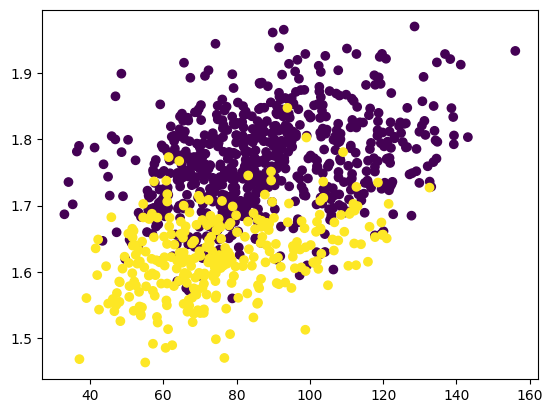

In [53]:
# Z ukazom plt.scatter naredimo scatter plot. Argument x označuje x os, y y os in c pa ciljno spremenljivko (razred).
plt.scatter(x=x_train[:, 1], y=x_train[:, 0], c=y_train)
plt.show()

3.a: Preveri, koliko podatkov v učni množici ima ciljno vrednost moški (0) in koliko ciljno vrednost ženska (1).

In [54]:
# Preverimo koliko vrednosti v y_train je manjših od 0.5 in dobljen vektor seštejemo s funkcijo sum(). 
# To lahko naredimo, ker se v numpyju true pripiše vrednost 1, false pa 0.
# Pri uporabi decimalnih vrednosti, je dobro biti pazljiv in ne uporabljati dvojnega enačaja za preverjanje enakosti (==). 
num_male = (y_train == 0).sum()
# Podobno preštejemo še število vrstic, ki imajo cilno vrednost, ki predstavlja žensko
num_female = (y_train == 1).sum()
print(f'Number of examples labled "Male": {num_male}')
print(f'Number of examples labled "Female": {num_female}')

Number of examples labled "Male": 700
Number of examples labled "Female": 300


Poglejmo si sedaj dva preprosta pristopa, ki ju pogosto uporabljamo kot minimalno napovedno točnost, ki jo lahko dosežemo:
- Majority classifier: Model za napovedovanje diskretne ciljne spremenljivke (klasifikacija - v našem primeru spol osebe)
- Mean classifier: Model za napovedovanje numerične ciljne spremenljivke (regresija - v našem primeru višina osebe)

3.b: Dopolni funkcijo majority classifier, ki sprejme učne množico (napovedne značilke in ciljne vrednosti) ter testno množico (napovedne značilke) in napove ciljne vrednosti za testno množico. Model deluje na predpostavki, da je distribucija učne množice enaka distribuciji podatkov v splošnem. Za vse testne podatke napove najbolj pogosto vrednost ciljne vrednosti učne množice.

<details>
  <summary>Namig:</summary>

  *Pomagaj si s [funkcijo numpy.unique](https://numpy.org/doc/stable/reference/generated/numpy.unique.html), ki sestavi vektor vseh vrednosti, ki se pojavijo v dani matriki*.

  Algoritem torej deluje na sledeč način:
  1. Najdi najbolj pogosto vrednost:
  - Sprehodi se čez vrednosti in si zabeleži kolikokrat si katero srečal, nato pa izberi tisto, ki se je pojavila največkrat
  - Za vse različne vrednosti ciljne spremenljivke preveri kolikokrat se je ta pojavila in izberi tisto, ki je najbolj pogosta
  2. Za vsak primer iz testne množice napovej najbolj pogosto vrednost
</details>


In [55]:
# Majority classifier: Poišči najbolj pogosto ciljno vrednost v učnih podatkih in jo uporabi kot napoved za vsak primer iz testne množice
def majority_class(x_train, y_train, x_test):
    # Najdemo edinstvene vrednosti in njihovo frekvenco v y_train
    vals, counts = np.unique(y_train, return_counts=True)
    # Izberemo vrednost z največjo frekvenco
    most_common = vals[np.argmax(counts)]
    # Za vsak primer v x_test napovemo najbolj pogost razred
    return np.full(shape=(x_test.shape[0],), fill_value=most_common, dtype=y_train.dtype)

Preverimo sedaj delovanje zgoraj definiranega modela. Naložimo učne in testne podatke ter preverimo koliko primerov naš model zadane.

In [56]:
# Naloži učne podatke s pomočjo funkcije np.load in jih razpakiraj v x_train in y_train
train = np.load("vaje1_train.npz")
x_train = train["x"]
y_train = train["y"]

# Naloži testne podatke in jih razpakiraj v x_test in y_test
test = np.load("vaje1_test.npz")
x_test = test["x"]
y_test = test["y"]

# Naredimo napovedi z napovednim modelom, ki napove najbolj pogost razred
y_pred = majority_class(x_train, y_train, x_test)

# Izračunamo koliko ciljnih vrednosti smo zadeli
print(f"Correctly predicted {(y_pred == y_test).sum()}/{y_test.shape[0]}")

Correctly predicted 600/1000


Vidimo, da distribucija ciljne vrednosti učne in testne množice ni enaka, zato zadanemo manj kot 70% primerov

Poglejmo še model mean classifier.

3.c: Dopolni funkcijo mean_classifier, ki sprejme učne množico (napovedne značilke in ciljne vrednosti) ter testno množico (napovedne značilke) in napove ciljne vrednosti za testno množico. Model najde povprečno vrednost ciljne vrednosti učne množice in jo napo za vsak primer iz testne množice.

In [57]:
def mean_classifier(x_train, y_train, x_test):
    # Napovej povprečno ciljno vrednost iz učne množice za vse primere v testni množici
    mean_value = np.mean(y_train)
    return np.full(shape=(x_test.shape[0],), fill_value=mean_value, dtype=float)

Poglejmo kako dobro naš model deluje.

In [58]:
# Naloži učne podatke s pomočjo funkcije np.load in jih razpakiraj v x_train in y_train
train = np.load("vaje1_train.npz")
# Prvi stolpec je višina, drugi teža
x_train = train["x"][:, 1]
y_train = train["x"][:, 0]

# Naloži testne podatke in jih razpakiraj v x_test in y_test
test = np.load("vaje1_test.npz")
x_test = test["x"][:, 1]
y_test = test["x"][:, 0]

# Naredimo napovedi z napovednim modelom, ki napove najbolj pogost razred
y_pred = mean_classifier(x_train, y_train, x_test)

# Izpiši napako kot povprečno absolutno razliko med napovedmi in pravilnimi vrednostmi mean(|y_pred-y_true|)
print(f"Average error {np.mean(np.abs(y_test-y_pred))}")

Average error 0.08363270707163153


## Dodatna naloga: Najbližji center

Če pogledamo vizualizacijo iz naloge 3 vidimo, da so primeri, ki predstavljajo moške skoncentrirani zgoraj desno, tisti ki predstavljajo ženske pa spodaj levo. Ta vzorec v podatkih lahko uporabimo, da modelu damo dodatno informacijo in ga posledično izboljšamo. Poglejmo si torej model, ki ga bomo poimenovali closest mean.

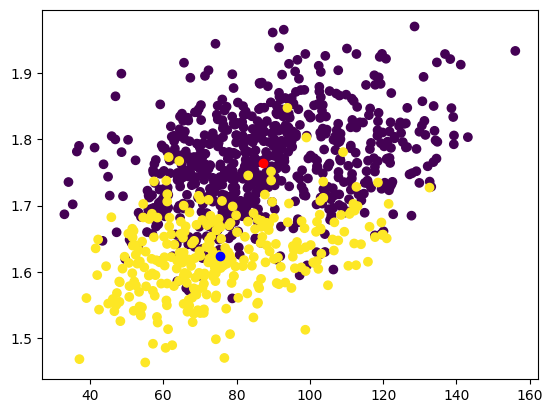

In [59]:
# Naloži učne podatke s pomočjo funkcije np.load in jih razpakiraj v x_train in y_train
train = np.load("vaje1_train.npz")
x_train = train["x"]
y_train = train["y"]

plt.scatter(x=x_train[:, 1], y=x_train[:, 0], c=y_train)
male_data_center = np.mean(x_train[y_train < 0.5], axis=0)
female_data = np.mean(x_train[y_train > 0.5], axis=0)

plt.scatter(x=male_data_center[1], y=male_data_center[0], c="red")
plt.scatter(x=female_data[1], y=female_data[0], c="blue")
plt.show()


D.a: Dopolni funkcijo closest_mean, ki sprejme učne množico (napovedne značilke in ciljne vrednosti) ter testno množico (napovedne značilke) in napove ciljne vrednosti za testno množico. Model poišče povprečne vrednosti (centre) za vsako vrednost ciljne vrednosti iz učne množice. Za podatek iz testne množice nato izračuna razdaljo do izračunanih centrov. Napoved za primer je ciljna vrednost, ki pripada najbližjemu centru.

In [60]:
# Closest mean: Poišči povprečno vrednost za vsako ciljno vrednost. Ciljno vrednost za vrstico iz teste množice določi kot ciljno vrednost, katere povprečna vrednost je najbližje.
# Pomagaš si lahko z maskami in funkcijama np.mean in np.argmin
def closest_mean(x_train, y_train, x_test):
    # Poiščemo centre (povprečja) za vsak razred v učni množici
    unique_labels = np.unique(y_train)
    centers = []
    for lbl in unique_labels:
        centers.append(np.mean(x_train[y_train == lbl], axis=0))
    centers = np.stack(centers, axis=0)  # shape: (num_labels, num_features)

    # Računamo evklidsko razdaljo od vsakega testnega vzorca do vsakega centra
    # Rezultat bo matrika (n_test, num_labels)
    diffs = x_test[:, None, :] - centers[None, :, :]
    dists = np.sqrt(np.sum(diffs * diffs, axis=2))

    # Za vsak testni primer izberemo label z najmanjšo razdaljo
    nearest_idx = np.argmin(dists, axis=1)
    return unique_labels[nearest_idx]


In [69]:
# Naloži učne podatke s pomočjo funkcije np.load in jih razpakiraj v x_train in y_train
train = np.load("vaje1_train.npz")
x_train = train["x"]
y_train = train["y"]

# Naloži testne podatke in jih razpakiraj v x_test in y_test
test = np.load("vaje1_test.npz")
x_test = test["x"]
y_test = test["y"]

# Naredimo napovedi z napovednim modelom, ki napove najbolj pogost razred
y_pred = closest_mean(x_train, y_train, x_test)

# Izračunamo koliko ciljnih vrednosti smo zadeli
print(f"Correctly predicted {(y_pred == y_test).sum()}/{y_test.shape[0]}")

Correctly predicted 623/1000


Vidimo lahko, da ta pristop deluje bolje, a ne veliko bolje.

Če še enkrat pogledamo podatke lahko opazimo, da imata spremenljivki višina in teža različno zalogo vrednosti in da bo zato teža bolj vplivala na napoved kot višina. To popravimo z normalizacijo (Zalogo vrednosti pretvorimo na interval med 0 in 1).

D.b: Dopolni funkcijo closest_mean2, ki deluje kot funkcija closest_mean, a podatke prej skrči na interval med 0 in 1 (pomagaš si lahko s funkcijo $X_n = \frac{X-\min(X)}{\max(X)-\min(X)}$). Pri implementaciji pazi, da za vsako napovedno značilko izračunaš minimalno in maksimalno vrednost le na učni množici.

In [62]:
def closest_mean2(x_train, y_train, x_test):
    # Normaliziramo značilke glede na učne podatke:
    # X_n = (X - min) / (max - min)
    mins = np.min(x_train, axis=0)
    maxs = np.max(x_train, axis=0)
    denom = maxs - mins
    # Izognemo se deljenju z 0, kjer je razpon 0 (v tem primeru ostane vrednost nespremenjena)
    denom[denom == 0] = 1

    x_train_norm = (x_train - mins) / denom
    x_test_norm = (x_test - mins) / denom

    # Uporabimo isti pristop kot v closest_mean, vendar na normaliziranih podatkih
    unique_labels = np.unique(y_train)
    centers = []
    for lbl in unique_labels:
        centers.append(np.mean(x_train_norm[y_train == lbl], axis=0))
    centers = np.stack(centers, axis=0)

    diffs = x_test_norm[:, None, :] - centers[None, :, :]
    dists = np.sqrt(np.sum(diffs * diffs, axis=2))
    nearest_idx = np.argmin(dists, axis=1)
    return unique_labels[nearest_idx]

Preverimo, če smo točnost našega modela izboljšali s tem popravkom.

In [71]:
# Naloži učne podatke s pomočjo funkcije np.load in jih razpakiraj v x_train in y_train
train = np.load("vaje1_train.npz")
x_train = train["x"]
y_train = train["y"]

# Naloži testne podatke in jih razpakiraj v x_test in y_test
test = np.load("vaje1_test.npz")
x_test = test["x"]
y_test = test["y"]

# Naredimo napovedi z napovednim modelom, ki napove najbolj pogost razred
y_pred = closest_mean2(x_train, y_train, x_test)

# Izračunamo koliko ciljnih vrednosti smo zadeli
print(f"Correctly predicted {(y_pred == y_test).sum()}/{y_test.shape[0]}")

Correctly predicted 855/1000


Vidimo lahko, da sedaj naš model deluje veliko boljše.